# Dynamic Nelson–Siegel (DNS) Yield Curve Model

In financial factor models, the unknown factors can be reasonably well explained by a few observable proxies, such as the Fama–French factors. Based on extension of DNS work and Jiaqing Fan's 2020 paper, we aim to more accurately estimate the percentage of both explained and unexplained components in factors and thus to assess the explanatory power of covariates.

## 0. Research Goal

## Goal: 
Estimate monthly DNS factors from yield curve data, then decompose each factor into an observable macro-driven component and an unobservable residual component.

**Model:**
```
\beta_t = g(x_t) + \gamma_t
```
where:
```
\gamma_t = \rho \gamma_{t-1} + \epsilon_t
```
The main versions tested are:
```
\beta_t = c + D x_t + \gamma_t
```
and
```
\beta_t = B \Phi(x_t) + \gamma_t
```
where Φ(x_t) is a nonlinear basis expansion.

## 1. Imports and Configuration

**Purpose:** centralize libraries, paths, plotting settings, and constants.

In [93]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
# from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge
# from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import mean_squared_error, r2_score
# from statsmodels.tsa.ar_model import AutoReg
# from statsmodels.tsa.stattools import adfuller

In [94]:
# Constants

DATA_DIR = Path("data")
YIELDS_PATH = DATA_DIR / "yields.csv"

DATE_COL = "observation_date"
LAMBDA = 0.0609

## 2. Load Daily Yield Curve Data

**Purpose:** import the raw yield curve data before making modeling choices.

The input data are daily Treasury yields across multiple maturities. The DNS model is estimated at monthly frequency, so the daily panel must first be converted into a monthly panel.

In [95]:
yields_daily = pd.read_csv(YIELDS_PATH, parse_dates=[DATE_COL])
yields_daily = yields_daily.set_index(DATE_COL).sort_index()
yields_daily.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
observation_date,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,0.05,0.08,0.18,0.45,1.09,1.66,2.65,3.36,3.85,4.60,4.65
2010-01-05,0.03,0.07,0.17,0.41,1.01,1.57,2.56,3.28,3.77,4.54,4.59
2010-01-06,0.03,0.06,0.15,0.40,1.01,1.60,2.60,3.33,3.85,4.63,4.70
2010-01-07,0.02,0.05,0.16,0.40,1.03,1.62,2.62,3.33,3.85,4.62,4.69


## 3. Convert Daily Yields to Monthly Yields

### 3.1 Monthly Sampling Decision

For the baseline model, monthly yields are defined using the first available trading day of each month. This aligns the yield curve with monthly macroeconomic covariates while preserving an end-of-period information set. Alternative choices include monthly averages or first-of-month observations.

In [96]:
# Chosen Monthly Yield Sampling Decision
yields_monthly = yields_daily.resample("ME").first()

# Alternative Monthly Yield Sampling Decision
# yields_monthly_avg = yields_daily.resample("ME").mean()
# yields_monthly_last = yields_daily.resample("ME").last()
# yields_monthly_first = yields_daily.resample("ME").first()

## 4. Define Maturities and Nelson-Siegel Loadings

**Purpose:** create the DNS design matrix.

In [97]:
maturity_map = {
    "DGS1MO": 1,
    "DGS3MO": 3,
    "DGS6MO": 6,
    "DGS1": 12,
    "DGS2": 24,
    "DGS3": 36,
    "DGS5": 60,
    "DGS7": 84,
    "DGS10": 120,
    "DGS20": 240,
    "DGS30": 360,
}

# Alternative maturity maps (Same data just different ways of displaying it)

# months_maturity_map = {
#     "DGS1MO": 1,
#     "DGS3MO": 3,
#     "DGS6MO": 6,
#     "DGS1": 12,
#     "DGS2": 24,
#     "DGS3": 36,
#     "DGS5": 60,
#     "DGS7": 84,
#     "DGS10": 120,
#     "DGS20": 240,
#     "DGS30": 360,
# }

# years_maturity_map = {
#     "DGS1MO": 1/12,
#     "DGS3MO": 3/12,
#     "DGS6MO": 6/12,
#     "DGS1": 1,
#     "DGS2": 2,
#     "DGS3": 3,
#     "DGS5": 5,
#     "DGS7": 7,
#     "DGS10": 10,
#     "DGS20": 20,
#     "DGS30": 30,
# }

The DNS model represents the yield curve at time t as a linear combination of level, slope, and curvature factors.

In [98]:
def ns_loadings(maturities, lam):
    tau = np.asarray(maturities)
    level = np.ones_like(tau)
    slope = (1 - np.exp(-lam * tau)) / (lam * tau)
    curvature = slope - np.exp(-lam * tau)
    return np.column_stack([level, slope, curvature])

## 5. Estimate Monthly DNS Factors β_t

**Purpose:** estimate level, slope, and curvature for every month.

In [99]:
def estimate_dns_factors(yields_df, maturity_map, lam):
    cols = list(maturity_map.keys())
    maturities = list(maturity_map.values())
    X = ns_loadings(maturities, lam)

    factors = []
    fitted_curves = []

    for date, row in yields_df[cols].dropna().iterrows():
        y = row.values
        beta_hat = np.linalg.lstsq(X, y, rcond=None)[0]
        y_hat = X @ beta_hat

        factors.append({
            "date": date,
            "beta_level": beta_hat[0],
            "beta_slope": beta_hat[1],
            "beta_curvature": beta_hat[2],
        })

        fitted_curves.append(pd.Series(y_hat, index=cols, name=date))

    factors = pd.DataFrame(factors).set_index("date")
    fitted_curves = pd.DataFrame(fitted_curves)

    return factors, fitted_curves

In [100]:
betas, fitted_curves = estimate_dns_factors(yields_monthly, maturity_map, LAMBDA)
betas.head()

,beta_level,beta_slope,beta_curvature
date,,,
2010-01-31,5.202583,-5.173316,-4.782471
2010-02-28,5.093480,-4.980952,-5.529436
2010-03-31,5.078589,-4.896319,-5.864412
2010-04-30,5.268621,-5.111659,-5.285412
2010-05-31,5.025803,-4.866552,-5.029487


## 6. DNS Factor Diagnostics

Determine whether the β factors make economic sense.

### 6.1 Plot Factors Over Time

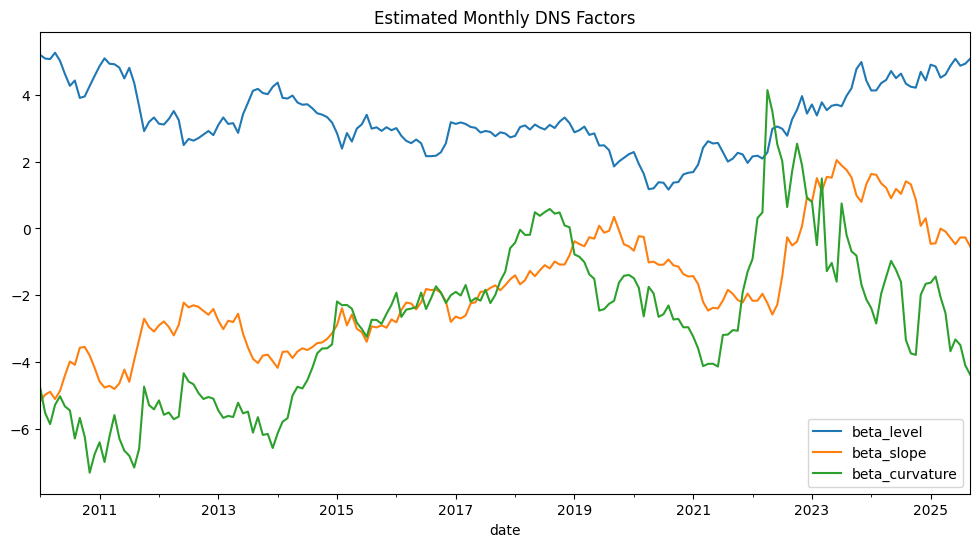

In [101]:
betas.plot(figsize=(12, 6), title="Estimated Monthly DNS Factors")
plt.show()

### 6.2 Plot Example Fitted Curves

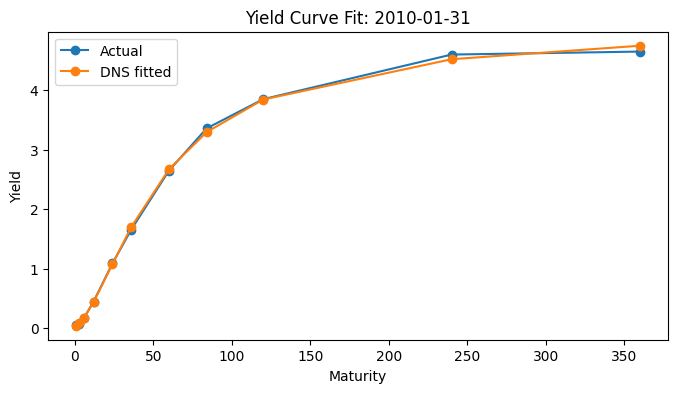

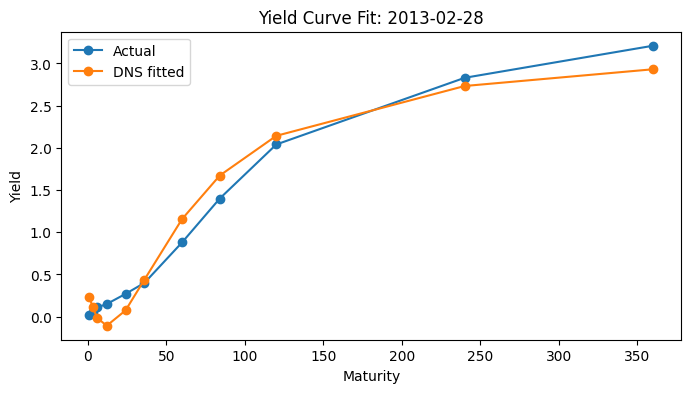

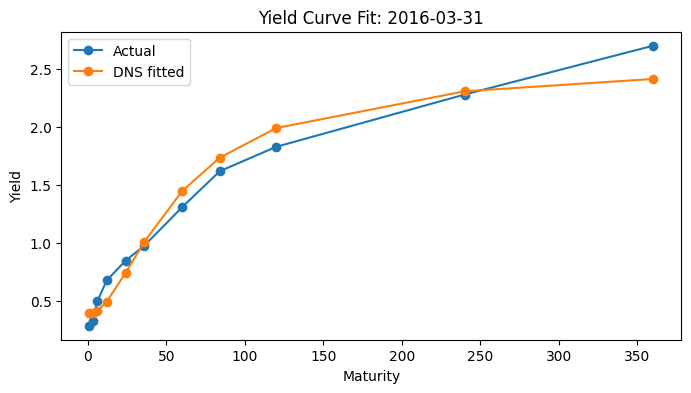

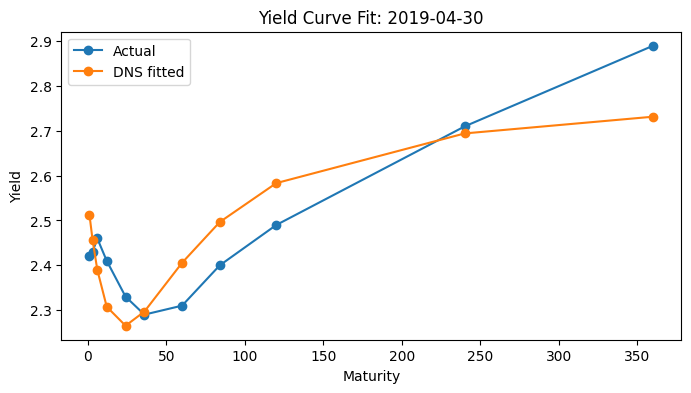

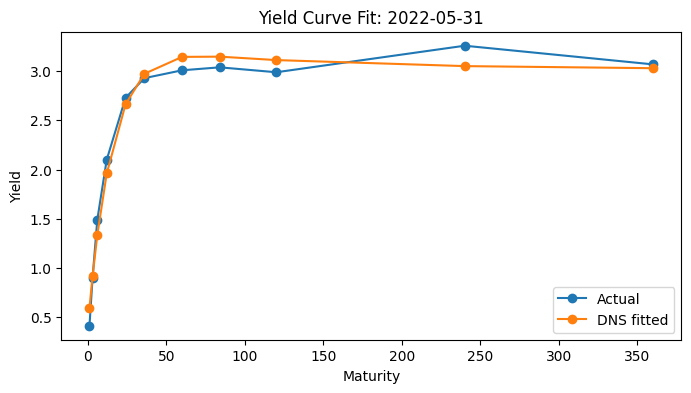

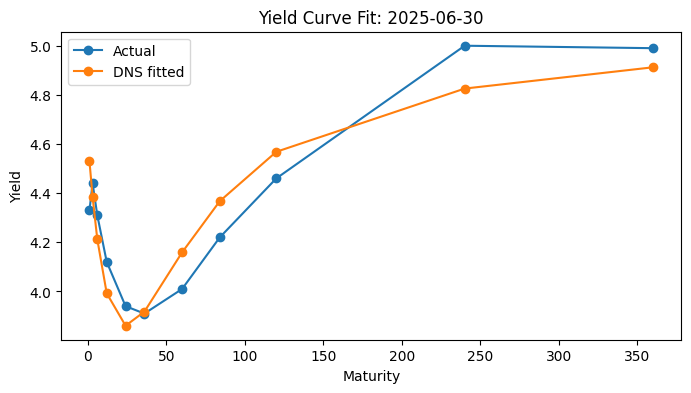

In [102]:
example_dates = betas.index[::len(betas)//5]

for date in example_dates:
    actual = yields_monthly.loc[date, list(maturity_map.keys())]
    fitted = fitted_curves.loc[date]

    plt.figure(figsize=(8, 4))
    plt.plot(list(maturity_map.values()), actual.values, marker="o", label="Actual")
    plt.plot(list(maturity_map.values()), fitted.values, marker="o", label="DNS fitted")
    plt.title(f"Yield Curve Fit: {date.date()}")
    plt.xlabel("Maturity")
    plt.ylabel("Yield")
    plt.legend()
    plt.show()

### 6.3 Fit Error Over Time

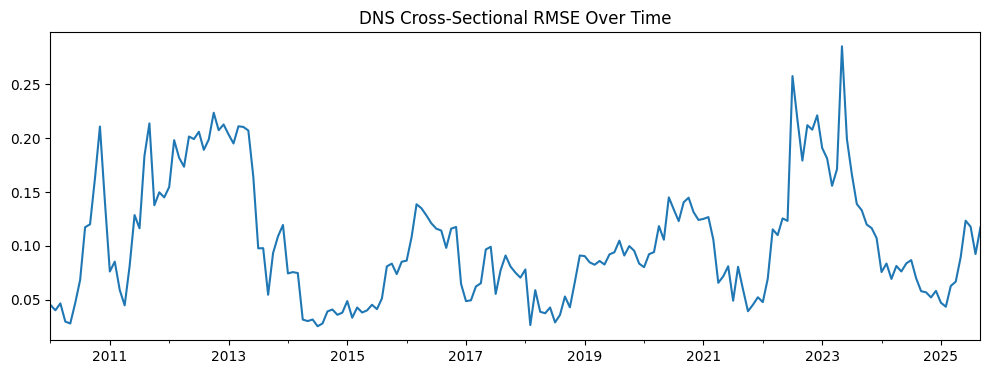

In [103]:
errors = yields_monthly[list(maturity_map.keys())].loc[fitted_curves.index] - fitted_curves
rmse_by_date = np.sqrt((errors ** 2).mean(axis=1))

rmse_by_date.plot(figsize=(12, 4), title="DNS Cross-Sectional RMSE Over Time")
plt.show()

## 7. Load Monthly Macroeconomic Covariates \(x_t\)

The next step is to build the observable covariate vector \(x_t\), which will be used to explain the estimated DNS factors:

```
\beta_t = g(x_t) + \gamma_t
```

The baseline covariates are selected to capture broad macroeconomic conditions that are likely related to the level, slope, and curvature of the yield curve.

The current covariates are:

| Variable | FRED Series | File | Reason for inclusion |
|---|---|---|---|
| Real activity proxy | INDPRO | `gdp.csv` | Industrial production is used as a monthly proxy for GDP growth because GDP is quarterly. |
| Inflation | CPIAUCSL | `cpi.csv` | CPI captures realized consumer price inflation. |
| Short rate | FEDFUNDS | `shortrate.csv` | The federal funds rate captures the short end of monetary policy conditions. |
| Oil prices | DCOILWTICO | `oil.csv` | Oil captures energy price shocks and inflationary pressure. |

GDP itself is not used in the baseline monthly model because GDP is usually quarterly. Since the DNS factors are estimated monthly, industrial production is used as a cleaner monthly real-activity proxy.

**Investigate crude oil price timeframe (future or not) **
also think about uncertainty indexes deep baker bloom indexes, include economic and/or geopolitical uncertainty indexes.
climate change data

In [104]:
GDP_PROXY_PATH = DATA_DIR / "gdp.csv"          # INDPRO
CPI_PATH = DATA_DIR / "cpi.csv"               # CPIAUCSL
SHORT_RATE_PATH = DATA_DIR / "shortrate.csv"  # FEDFUNDS
OIL_PATH = DATA_DIR / "oil.csv"               # DCOILWTICO


def load_fred_csv(path, value_name):
    """
    Load a FRED CSV with columns DATE and one value column.
    Returns a DataFrame indexed by DATE with the value column renamed.
    """
    df = pd.read_csv(path, parse_dates=[DATE_COL])
    df = df.set_index(DATE_COL).sort_index()

    # FRED CSVs usually have one non-date column.
    value_cols = [col for col in df.columns if col != DATE_COL]
    if len(value_cols) != 1:
        raise ValueError(f"Expected one value column in {path}, found {value_cols}")

    df = df.rename(columns={value_cols[0]: value_name})
    return df


gdp_proxy_raw = load_fred_csv(GDP_PROXY_PATH, "gdp")
cpi_raw = load_fred_csv(CPI_PATH, "cpi")
short_rate_raw = load_fred_csv(SHORT_RATE_PATH, "short_rate")
oil_raw = load_fred_csv(OIL_PATH, "oil_price")

gdp_proxy_raw.head(), cpi_raw.head(), short_rate_raw.head(), oil_raw.head()

(                     gdp
 observation_date        
 1919-01-01        4.8739
 1919-02-01        4.6585
 1919-03-01        4.5238
 1919-04-01        4.6046
 1919-05-01        4.6315,
                     cpi
 observation_date       
 1947-01-01        21.48
 1947-02-01        21.62
 1947-03-01        22.00
 1947-04-01        22.00
 1947-05-01        21.95,
                   short_rate
 observation_date            
 1954-07-01              0.80
 1954-08-01              1.22
 1954-09-01              1.07
 1954-10-01              0.85
 1954-11-01              0.83,
                   oil_price
 observation_date           
 1986-01-02            25.56
 1986-01-03            26.00
 1986-01-06            26.53
 1986-01-07            25.85
 1986-01-08            25.87)

## 8. Preprocess and Transform Covariates

The raw macro series are transformed into economically meaningful variables.

The transformed covariates are:

```
x_t =
[
\Delta \log(\text{INDPRO}_t),
\Delta \log(\text{CPI}_t),
\Delta \log(\text{Oil}_t),
\text{ShortRate}_t
]
```

Industrial production, CPI, and oil prices are transformed using monthly log differences. This makes them approximate monthly growth or inflation rates. The short rate is kept in levels because interest rates are already measured as rates.

Oil prices are originally daily, so they are converted to monthly frequency before the log growth transformation. The baseline uses the monthly average oil price because oil is noisy at daily frequency.

oil price should be at an absolute level not the price change

In [105]:
# Convert all series to monthly frequency and month-end labels.
# INDPRO, CPI, and FEDFUNDS are already monthly but may be indexed at month-start.
# The following standardizes them to month-end labels.

gdp_m = gdp_proxy_raw.resample("ME").last()
cpi_m = cpi_raw.resample("ME").last()
short_rate_m = short_rate_raw.resample("ME").last()

# Oil is daily, so aggregate to monthly.
# Monthly average is preferred for oil because daily oil prices are noisy.
# oil_m = oil_raw.resample("ME").mean()

# Using monthly first to match with the rest of the data
oil_m = oil_raw.resample("ME").first()

# Combine raw monthly levels.
macro_levels = pd.concat(
    [gdp_m, cpi_m, oil_m, short_rate_m],
    axis=1
)

# Convert missing value placeholders if needed.
macro_levels = macro_levels.apply(pd.to_numeric, errors="coerce")

macro_levels.head()

,gdp,cpi,oil_price,short_rate
observation_date,,,,
1919-01-31,4.8739,NaN,NaN,NaN
1919-02-28,4.6585,NaN,NaN,NaN
1919-03-31,4.5238,NaN,NaN,NaN
1919-04-30,4.6046,NaN,NaN,NaN
1919-05-31,4.6315,NaN,NaN,NaN


In [106]:
# Transform into model covariates.

macro_covariates = pd.DataFrame(index=macro_levels.index)

macro_covariates["gdp_growth"] = np.log(macro_levels["gdp"]).diff()
macro_covariates["cpi_inflation"] = np.log(macro_levels["cpi"]).diff()
macro_covariates["oil_growth"] = np.log(macro_levels["oil_price"]).diff()

# FEDFUNDS is in percent units, so divide by 100 if yields are also in decimals.
# If your yield data are still in percent units, keep this unscaled.
macro_covariates["short_rate"] = macro_levels["short_rate"]

macro_covariates = macro_covariates.dropna()

# Use this only if yields are converted from percent to decimals.
macro_covariates["short_rate"] = macro_levels["short_rate"] / 100

macro_covariates.head()

,gdp_growth,cpi_inflation,oil_growth,short_rate
observation_date,,,,
1986-02-28,-0.007044,-0.001821,-0.383410,0.0786
1986-03-31,-0.007148,-0.005484,-0.374380,0.0748
1986-04-30,0.001433,-0.003673,-0.073594,0.0699
1986-05-31,0.001476,0.002756,0.215024,0.0685
1986-06-30,-0.004037,0.003663,0.000000,0.0692


## 9. Align DNS Factors and Covariates

The estimated DNS factors and macro covariates must be aligned on the same monthly date index.

The DNS factors are estimated from month-end yield curves. The macro covariates are also standardized to month-end labels. The merged dataset keeps only months where both DNS factors and covariates are available.

There are two possible timing conventions:

1. **Explanatory decomposition:** use same-month covariates \(x_t\) to explain \(\beta_t\).
2. **Forecasting / real-time prediction:** use lagged covariates \(x_{t-1}\) to explain \(\beta_t\), which avoids look-ahead bias.

The baseline below uses same-month covariates for decomposition. A lagged version is also created for forecasting robustness.

In [107]:
# Same-month explanatory dataset.
model_data = betas.join(macro_covariates, how="inner")

model_data.head()

,beta_level,beta_slope,beta_curvature,gdp_growth,cpi_inflation,oil_growth,short_rate
date,,,,,,,
2010-01-31,5.202583,-5.173316,-4.782471,0.010841,0.000649,0.039152,0.0011
2010-02-28,5.093480,-4.980952,-5.529436,0.003746,-0.000952,-0.091258,0.0013
2010-03-31,5.078589,-4.896319,-5.864412,0.006833,0.000331,0.056180,0.0016
2010-04-30,5.268621,-5.111659,-5.285412,0.003387,0.000230,0.071336,0.0020
2010-05-31,5.025803,-4.866552,-5.029487,0.013419,-0.000520,0.019448,0.0020


In [108]:
# Optional lagged-covariate dataset for forecasting or look-ahead-bias checks.

macro_covariates_lagged = macro_covariates.shift(1)

model_data_lagged = betas.join(macro_covariates_lagged, how="inner").dropna()

model_data_lagged.head()

,beta_level,beta_slope,beta_curvature,gdp_growth,cpi_inflation,oil_growth,short_rate
date,,,,,,,
2010-01-31,5.202583,-5.173316,-4.782471,0.004050,0.000520,0.003962,0.0012
2010-02-28,5.093480,-4.980952,-5.529436,0.010841,0.000649,0.039152,0.0011
2010-03-31,5.078589,-4.896319,-5.864412,0.003746,-0.000952,-0.091258,0.0013
2010-04-30,5.268621,-5.111659,-5.285412,0.006833,0.000331,0.056180,0.0016
2010-05-31,5.025803,-4.866552,-5.029487,0.003387,0.000230,0.071336,0.0020


In [109]:
print("DNS factors date range:")
print(betas.index.min(), "to", betas.index.max())

print("\nMacro covariates date range:")
print(macro_covariates.index.min(), "to", macro_covariates.index.max())

print("\nAligned model data date range:")
print(model_data.index.min(), "to", model_data.index.max())

print("\nNumber of aligned monthly observations:", len(model_data))

DNS factors date range:
2010-01-31 00:00:00 to 2025-09-30 00:00:00

Macro covariates date range:
1986-02-28 00:00:00 to 2026-03-31 00:00:00

Aligned model data date range:
2010-01-31 00:00:00 to 2025-09-30 00:00:00

Number of aligned monthly observations: 189


## 10. Exploratory Data Analysis

Before fitting the macro model, inspect the estimated DNS factors and transformed covariates.

The goals of this section are:

1. Check whether the DNS factors behave reasonably over time.
2. Check whether transformed covariates have large outliers or missing periods.
3. Inspect correlations between DNS factors and macro covariates.
4. Identify whether standardization is needed before regression.

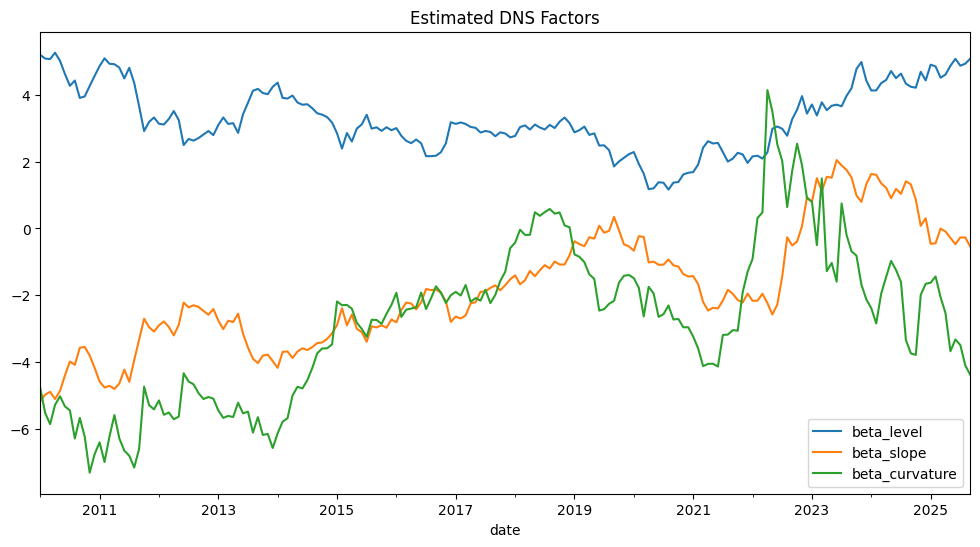

In [110]:
factor_cols = ["beta_level", "beta_slope", "beta_curvature"]
covariate_cols = ["gdp_growth", "cpi_inflation", "oil_growth", "short_rate"]

model_data[factor_cols].plot(
    figsize=(12, 6),
    title="Estimated DNS Factors"
)
plt.show()

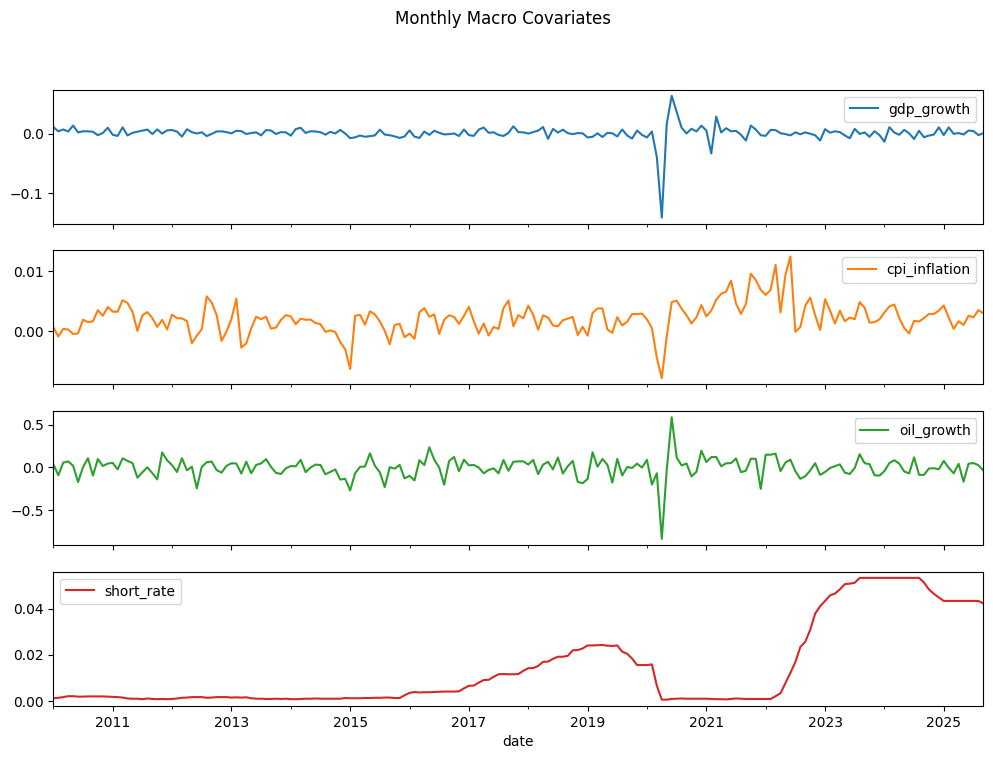

In [111]:
model_data[covariate_cols].plot(
    figsize=(12, 8),
    title="Monthly Macro Covariates",
    subplots=True
)
plt.show()

In [112]:
# Summary statistics

model_data[factor_cols + covariate_cols].describe()

,beta_level,beta_slope,beta_curvature,gdp_growth,cpi_inflation,oil_growth,short_rate
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000
mean,3.294703,-1.818898,-2.826014,0.000741,0.002116,-0.000914,0.013763
std,0.980225,1.734765,2.311628,0.013488,0.002595,0.116880,0.018008
min,1.165893,-5.173316,-7.320764,-0.141422,-0.007952,-0.835821,0.000500
25%,2.666633,-2.965880,-4.794493,-0.002632,0.000649,-0.060077,0.001000
50%,3.120458,-2.162892,-2.538434,0.001171,0.002131,0.008703,0.002000
75%,4.060594,-0.474584,-1.510121,0.004886,0.003209,0.063710,0.021900
max,5.268621,2.051632,4.147285,0.063472,0.012483,0.587618,0.053300


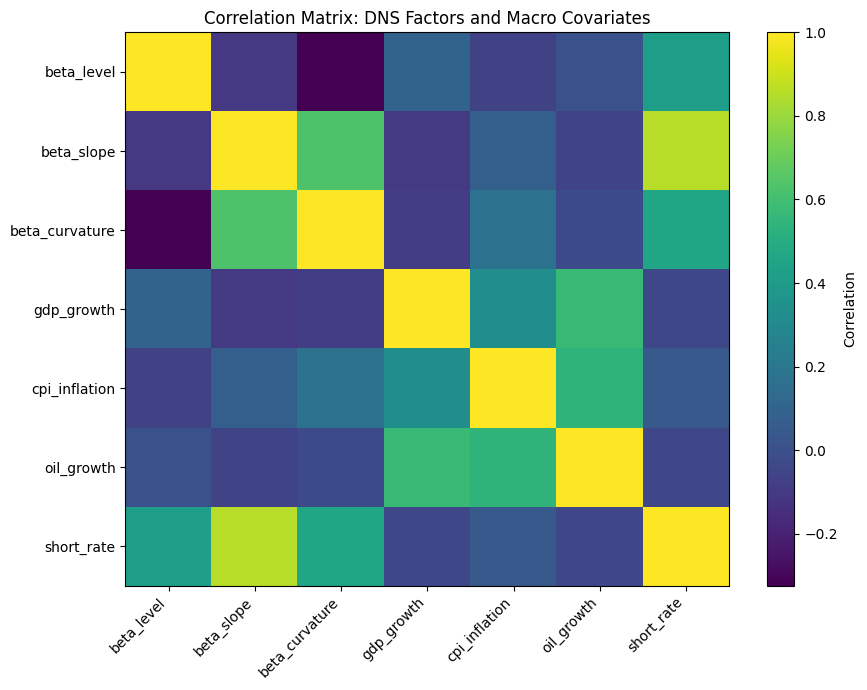

,beta_level,beta_slope,beta_curvature,gdp_growth,cpi_inflation,oil_growth,short_rate
beta_level,1.000000,-0.102854,-0.323736,0.098268,-0.063735,0.008350,0.416703
beta_slope,-0.102854,1.000000,0.632464,-0.099389,0.077329,-0.050357,0.858113
beta_curvature,-0.323736,0.632464,1.000000,-0.084503,0.171261,-0.025809,0.453989
gdp_growth,0.098268,-0.099389,-0.084503,1.000000,0.323506,0.570023,-0.037733
cpi_inflation,-0.063735,0.077329,0.171261,0.323506,1.000000,0.537455,0.047538
oil_growth,0.008350,-0.050357,-0.025809,0.570023,0.537455,1.000000,-0.040912
short_rate,0.416703,0.858113,0.453989,-0.037733,0.047538,-0.040912,1.000000


In [ ]:
# Correlation matrix

corr = model_data[factor_cols + covariate_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix: DNS Factors and Macro Covariates")
plt.tight_layout()
plt.show()

corr

#flip color scheme

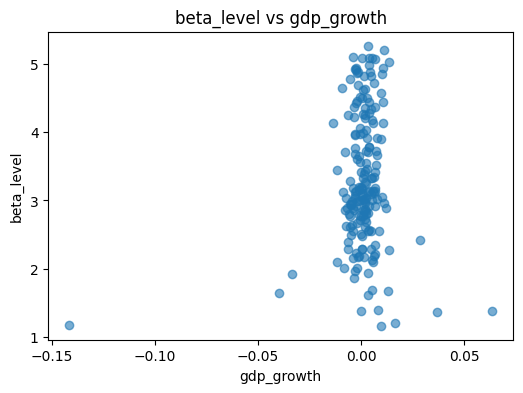

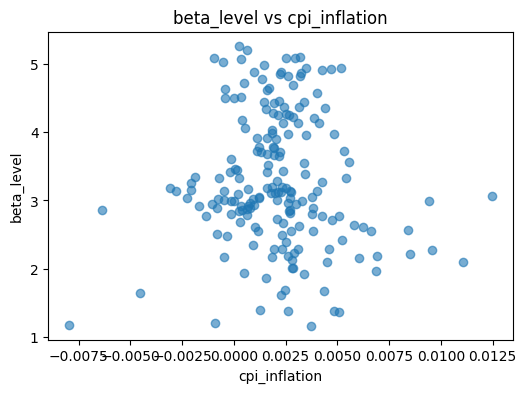

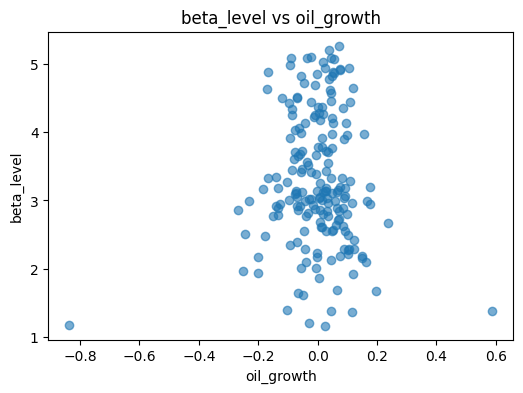

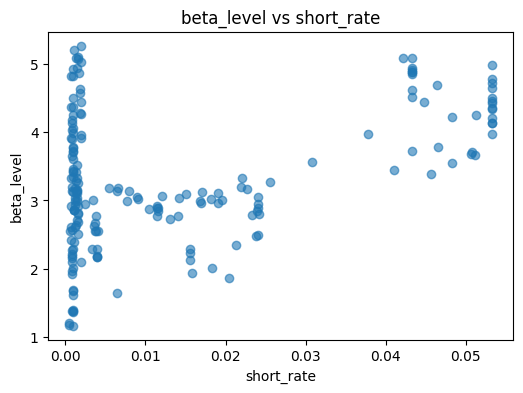

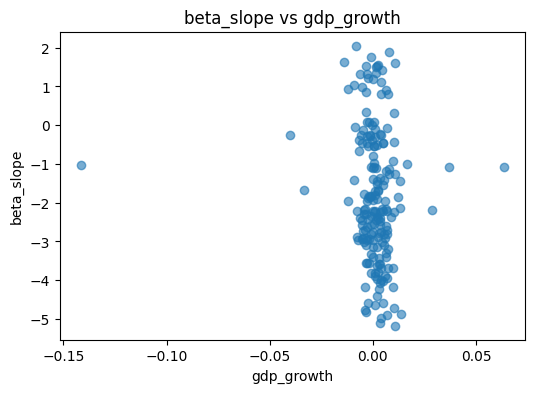

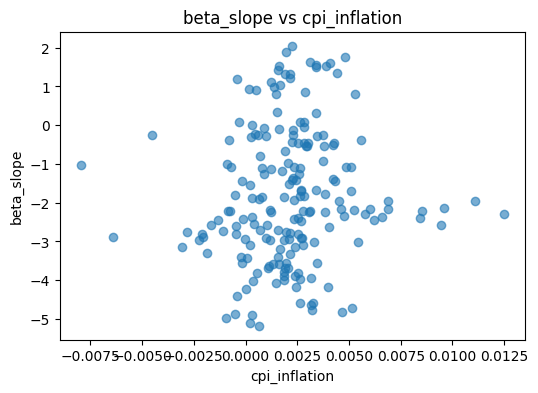

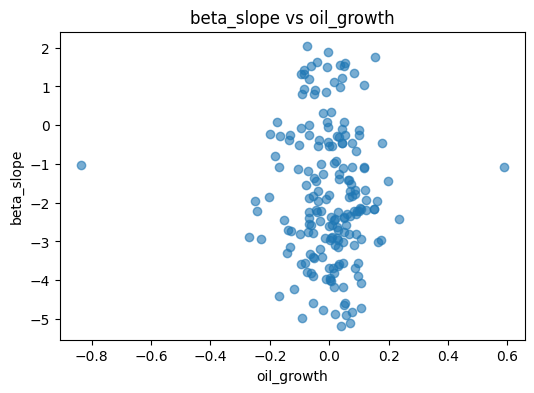

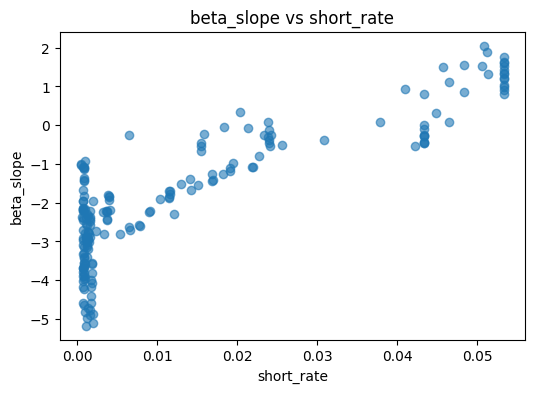

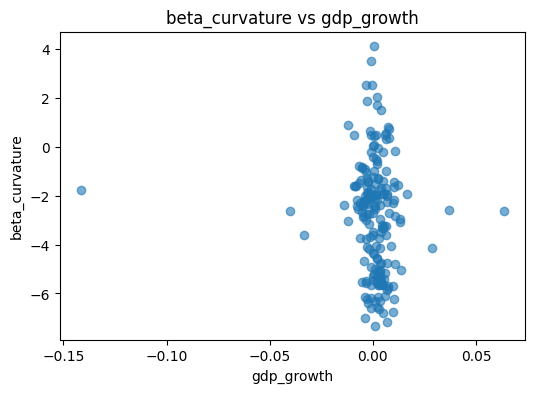

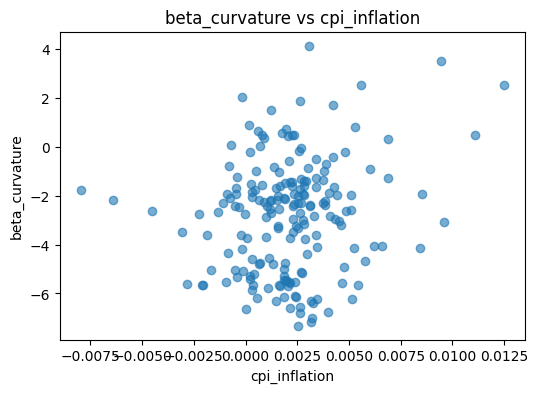

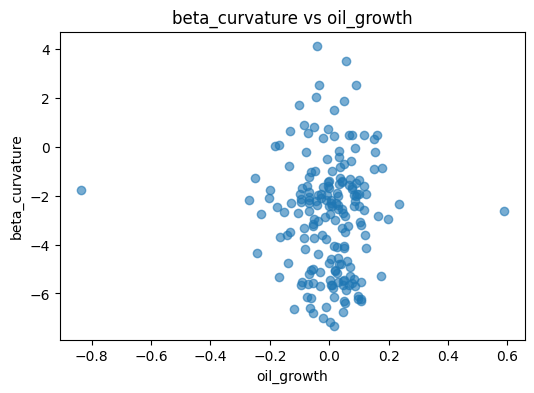

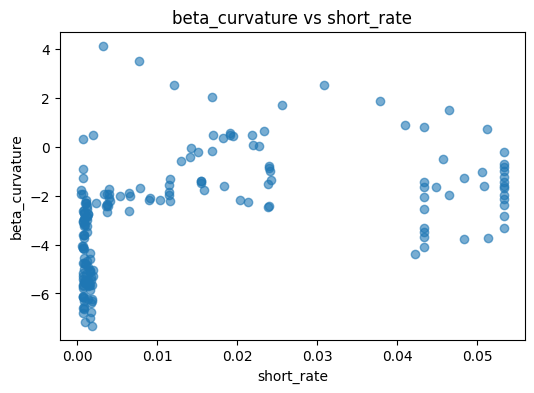

In [ ]:
# need to do regression to find significance and error gamma as AR(1) process
# least squares is inappropriate
# Fan uses PCA
# it should have a very large value with a small 1
# should be a big value at 1 lag, then all the other should be small
# model the residuals of gamma t as an AR(1)
# then we can inject NGFS scenarios (the world climate scenarios i guess)
# then plug into y_t model and see what we get for a forecast
# accuracy of the model is computing MSE of out of sample forecast, then we check if we have these values from NGFS does the yield curve go along this path
# need to find out out of sample accuracy
# based on what fan writes its not going to be very accurate
# They design the factors by significance first then decide how much they contribute
# reread first 2 pages of the Fan paper

# Scatter plots: each DNS factor against each covariate.

for beta_col in factor_cols:
    for x_col in covariate_cols:
        plt.figure(figsize=(6, 4))
        plt.scatter(model_data[x_col], model_data[beta_col], alpha=0.6)
        plt.xlabel(x_col)
        plt.ylabel(beta_col)
        plt.title(f"{beta_col} vs {x_col}")
        plt.show()

## 11. Linear Macro Model

The first macro decomposition model assumes that each DNS factor can be decomposed into a linear component explained by observed macro covariates and a residual component:

\[
\beta_t = c + D x_t + \gamma_t
\]

where:

\[
x_t =
[
\Delta \log(\text{INDPRO}_t),
\Delta \log(\text{CPI}_t),
\Delta \log(\text{Oil}_t),
\text{ShortRate}_t
]
\]

In this baseline implementation, each DNS factor is regressed separately on the macro covariates. The fitted value is interpreted as the observable macro-driven component, while the residual is interpreted as the unexplained component.

This is the first-pass decomposition. Later versions can model the residual component \(\gamma_t\) as an AR(1) process.

In [115]:
# from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import r2_score, mean_squared_error

# X = model_data[covariate_cols]
# Y = model_data[factor_cols]

# linear_results = {}
# linear_fitted = pd.DataFrame(index=model_data.index)
# linear_residuals = pd.DataFrame(index=model_data.index)

# for beta_col in factor_cols:
#     y = Y[beta_col]

#     model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regression", LinearRegression())
#     ])

#     model.fit(X, y)

#     y_hat = model.predict(X)
#     resid = y - y_hat

#     linear_fitted[f"{beta_col}_fitted_macro"] = y_hat
#     linear_residuals[f"{beta_col}_residual"] = resid

#     linear_results[beta_col] = {
#         "model": model,
#         "r2": r2_score(y, y_hat),
#         "rmse": np.sqrt(mean_squared_error(y, y_hat)),
#         "intercept": model.named_steps["regression"].intercept_,
#         "coefficients": pd.Series(
#             model.named_steps["regression"].coef_,
#             index=covariate_cols
#         )
#     }

# linear_summary = pd.DataFrame({
#     beta_col: {
#         "r2": linear_results[beta_col]["r2"],
#         "rmse": linear_results[beta_col]["rmse"],
#     }
#     for beta_col in factor_cols
# }).T

# linear_summary